## Bayesian Causal Forest for HTE
**Model**: BCF for outcomes (probit link): model baseline μ(X) and treatment effect surface τ(X) with treatment A and include PS p(X) (or logit PS) as a covariate to correct for targeted selection.

BART is modelled with a PROBIT link function
$$Y_i = \mu_{i}(X, \hat{p}) + \tau_i(X) \cdot T_i$$

- $\mu(x_i, \pi_i)$ = the **prognostic function** — captures baseline outcome risk, regardless of treatment. $\pi_i$ are the propensity score estimates.
- $\tau(x_i)$ = the **treatment effect function** — captures how the treatment effect varies with covariates (this is CATE)
- $T \in {0,1}$ is the treatment indicator

In [1]:
import os
import sys
import seaborn as sns
from scipy.stats import norm
from sklearn.ensemble import HistGradientBoostingClassifier
import pymc as pm
import pymc_bart as pmb
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from ISYE6420.Project.bcf_vis import build_ite_rd, plot_gates, build_clan_table, print_clan_table
rng = np.random.default_rng(123)

output_folder = "ISYE6420/Project/"

## Data Loading and Preparation

In [2]:
# Import configurations
dx_name = "asthma"
version = "v7_040226"

cohort = pd.read_csv(f"ISYE6420\\Project\\data\\asthma_CP_cohort.csv")
print(len(cohort))

65417


In [3]:
y = cohort["outcome"].values
treatment = cohort["exposure"].values
follow_up_time = cohort["follow_up_time"].values
# Convert to binary indicator for outcome
y_data = (y > 0).astype(int)


### 1. Prognostic Model $\mu(X, \hat{p})$

In [4]:
X = cohort.drop(columns=["patid", "outcome", "exposure", "follow_up_time", "weight", "ps_score"])
# convert True False columns to int
X = X.astype(int)
# Logit transform the propensity scores for better modeling
propensity_score = cohort["ps_score"]
eps = 1e-6
ps_values = np.clip(propensity_score, eps, 1 - eps)
logit_ps = np.log(ps_values / (1 - ps_values))
X['logit_ps'] = logit_ps
X_mu = X.values

prognostic_model_config = {
    "n_trees": 50,
    "beta_prior": 3,
    "alpha_prior": 0.95,
}

In [5]:
num_exac_pats = cohort[cohort['outcome'] > 0]['patid'].nunique()/ cohort['patid'].nunique()
print(f"Proportion of patients with at least one event: {num_exac_pats:.2%}")

Proportion of patients with at least one event: 8.44%


In [6]:
X.columns

Index(['age', 'gina_step', 'total_exac_count', 'num_treatments_baseline',
       'num_outpatient_event', 'num_er_event', 'cp_count', 'hba1c_missing',
       'atopic_disease_flag', 'ckd_flag', 'dyslipidemia_flag',
       'eosinophilic_disease_flag', 'heart_failure_flag', 'hypertension_flag',
       'ischemic_stroke_flag', 'nasal_polyps_flag',
       'obstructive_sleep_apnea_flag', 't2dm_flag', 'bmi_20_25',
       'bmi_above_25', 'bmi_present', 'Acute_IHD_flag', 'CAD_flag', 'PVD_flag',
       'Biologics_flag', 'ICS_flag', 'ICS_LABA_flag', 'ICS_LABA_LAMA_flag',
       'LTRA_flag', 'OCS_flag', 'SABA_flag', 'SABA_SAMA_flag', 'sex_Female',
       'region_Midwest', 'region_Northeast', 'region_South',
       'region_Southwest', 'region_West', 'logit_ps'],
      dtype='str')

### 2. $\tau$(X) Treatment Effect Model


In [7]:
# Treatment indicator as int
T = treatment.astype(int)

# Feature matrix for tau: same covariates as mu, but add treatment indicator instead of propensity score
#X["T"] = T
X_tau = X.values.astype(float)

tau_model_config = {
    "n_trees": 50,       # stronger regularisation toward zero for treatment effects
    "beta_prior": 3,     # more shrinkage towards homogenenous treatment effects
    "alpha_prior": 0.25,
}


### Create prior for baseline risk

In [8]:
#filter out treated patients
comparator_mask = (T == 0)

# Train baseline model on unexposed patients
prognostic_model = HistGradientBoostingClassifier(random_state=123)
prognostic_model.fit(X[comparator_mask], y_data[comparator_mask])

# predict baseline risk for all patients
baseline_risk = prognostic_model.predict_proba(X_mu)[:, 1]

# clip baseline risk to avoid extreme values
baseline_risk = np.clip(baseline_risk, 1e-3, 1 - 1e-3)

# convert to probit scale
mu_prior = norm.ppf(baseline_risk) - num_exac_pats  # center around the mean of the outcome


## 3. Run Model

In [9]:
with pm.Model() as bcf_joint:

    X_mu_shared  = pm.Data("X_mu",  X_mu)
    X_tau_shared = pm.Data("X_tau", X_tau)
    T_shared = pm.Data("T", T.astype(float))
    y_obs = pm.Data("y_obs", y_data)

    # Prognosis model
    mu_residual = pmb.BART(
        "mu_residual",
        X_mu_shared,
        y_data.astype(float),
        m=prognostic_model_config["n_trees"],
        alpha=prognostic_model_config["alpha_prior"],
        beta=prognostic_model_config["beta_prior"],
        response="constant"
    )

    # Treatment effect
    tau = pmb.BART(
        "tau",
        X_tau_shared,
        y_data.astype(float),
        m=tau_model_config["n_trees"],
        alpha=tau_model_config["alpha_prior"],
        beta=tau_model_config["beta_prior"],
        response="constant"
    )

    constant_intercept = norm.ppf(num_exac_pats)

    # The Latent Propensity
    eta = mu_prior + mu_residual + tau * T_shared + constant_intercept
    
    # Bernoulli Likelihood with Probit link
    p = pm.math.invprobit(eta)
    y_likelihood = pm.Bernoulli("y_likelihood", p=p, observed=y_obs)

    trace_bcf = pm.sample(2500, tune=7000, chains=4, nuts_sampler_kwargs={"target_accept": 0.9}, random_seed=123)

ppc = pm.sample_posterior_predictive(trace_bcf, model=bcf_joint)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>PGBART: [mu_residual]
>PGBART: [tau]


Output()

Sampling 4 chains for 7_000 tune and 2_500 draw iterations (28_000 + 10_000 draws total) took 8594 seconds.


MemoryError: Unable to allocate 19.5 MiB for an array with shape (65417, 39) and data type float64

In [ ]:
# Extract CATTs from joint model
mu_joint  = trace_bcf.posterior["mu_residual"].mean(dim=["chain", "draw"]).values
tau_joint = trace_bcf.posterior["tau"].mean(dim=["chain", "draw"]).values
tau_joint_sd = trace_bcf.posterior["tau"].std(dim=["chain", "draw"]).values

print(f"Joint CATT summary — mean: {tau_joint.mean():.4f}, sd: {tau_joint.std():.4f}")
print(f"ATT (treated only): {tau_joint[T == 1].mean():.4f}")

Joint CATT summary — mean: -0.1301, sd: 0.0856
ATT (treated only): -0.0991


In [ ]:
az.to_netcdf(trace_bcf, f"{output_folder}bcf_{dx_name}_binary_CP.nc")

'ISYE6420/Project/bcf_asthma_binary_CP.nc'

## Load existing trace and compute CATE estimates

In [ ]:
#Load trace from nc file
#trace_bcf = az.from_netcdf(f"{output_folder}bcf_{dx_name}_binary_CP.nc")

In [ ]:
# with pm.Model() as bcf_joint:

#     X_mu_shared  = pm.Data("X_mu",  X_mu)
#     X_tau_shared = pm.Data("X_tau", X_tau)
#     T_shared = pm.Data("T", T.astype(float))
#     y_obs = pm.Data("y_obs", y_data)
#     offset = pm.Data("offset", follow_up_time)

#     # Prognosis model
#     mu = pmb.BART(
#         "mu_residual",
#         X_mu_shared,
#         y_data.astype(float),
#         m=prognostic_model_config["n_trees"],
#         alpha=prognostic_model_config["alpha_prior"],
#         beta=prognostic_model_config["beta_prior"],
#         response="constant"
#     )

#     # Treatment effect
#     tau = pmb.BART(
#         "tau",
#         X_tau_shared,
#         y_data.astype(float),
#         m=tau_model_config["n_trees"],
#         alpha=tau_model_config["alpha_prior"],
#         beta=tau_model_config["beta_prior"],
#         response="constant"
#     )

#     # # Use a tight intercept prior to ensure the model starts with a reasonable baseline risk
#     constant_intercept = norm.ppf(num_exac_pats)

#     # The Latent Propensity
#     eta = mu + tau * T_shared + constant_intercept
    
#     # Bernoulli Likelihood with Probit link
#     p = pm.math.invprobit(eta)
#     y_likelihood = pm.Bernoulli("y_likelihood", p=p, observed=y_obs)

# # Now you can run PPC using the trace loaded from the .nc file
# with bcf_joint:
#     ppc = pm.sample_posterior_predictive(trace_bcf)

In [ ]:
summary = az.summary(trace_bcf, var_names=["tau"], filter_vars="like")
print(f"Patients with R-hat > 1.01: {len(summary[summary['r_hat'] > 1.01])}")
print(f"\nMedian ESS (bulk): {summary['ess_bulk'].median():.0f}")
print(f"Patients with ESS < 100: {(summary['ess_bulk'] < 100).sum()}")

Patients with R-hat > 1.01: 43579

Median ESS (bulk): 1242
Patients with ESS < 100: 5108


In [ ]:
import xarray as xr
# --- ATT ---
tau = trace_bcf.posterior["tau"]
# Boolean index of treated patients
treated_mask = T.astype(bool)  # shape (66000,)

# Mean over treated patients within each (chain, draw)
# Result shape: (4, 2000)
att_draws = tau.values[:, :, treated_mask].mean(axis=-1)

# Wrap in xarray for ArviZ (needs chain/draw dims)
att_xr = xr.DataArray(
    att_draws,
    dims=["chain", "draw"]
)
rhat_att = az.rhat(xr.Dataset({"ATT": att_xr}))
ess_att  = az.ess(xr.Dataset({"ATT": att_xr}))
print(rhat_att, ess_att)

tau_mean = tau.values.reshape(-1, tau.shape[-1]).mean(axis=0)  # (66000,)
decile_labels = pd.qcut(tau_mean[treated_mask], q=10, labels=False)

n_chains, n_draws = tau.shape[:2]
n_deciles = 10
gates_draws = np.zeros((n_chains, n_draws, n_deciles))

for d in range(n_deciles):
    decile_idx = np.where(decile_labels == d)[0]
    gates_draws[:, :, d] = tau.values[:, :, treated_mask][:, :, decile_idx].mean(axis=-1)

gates_xr = xr.DataArray(
    gates_draws,
    dims=["chain", "draw", "decile"]
)
rhat_gates = az.rhat(xr.Dataset({"GATES": gates_xr}))
ess_gates  = az.ess(xr.Dataset({"GATES": gates_xr}))
print(rhat_gates)
print(ess_gates)

<xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    ATT      float64 8B 1.004 <xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    ATT      float64 8B 3.793e+03
<xarray.Dataset> Size: 80B
Dimensions:  (decile: 10)
Dimensions without coordinates: decile
Data variables:
    GATES    (decile) float64 80B 1.013 1.008 1.004 1.004 ... 1.004 1.004 1.005
<xarray.Dataset> Size: 80B
Dimensions:  (decile: 10)
Dimensions without coordinates: decile
Data variables:
    GATES    (decile) float64 80B 2.162e+03 2.676e+03 ... 2.554e+03 2.183e+03


In [ ]:
print(rhat_gates["GATES"].values)

[1.01278178 1.00822386 1.00421933 1.00368864 1.00342134 1.00380467
 1.00367075 1.0041092  1.00428683 1.00490918]


## Decision Tree Proxy for CATTs that are clinically interpretable

In [ ]:
from sklearn.tree import DecisionTreeRegressor
# 1. Take the mean estimated treatment effect for each patient
catt_estimates = trace_bcf.posterior["tau"].mean(dim=["chain", "draw"]).values
sorted_catt = np.sort(catt_estimates)
catt_rate_ratios = np.exp(catt_estimates)
y_proxy = catt_estimates

# Drop region columns if they exist, since they are not clinically interpretable
administrative_cols = [col for col in X.columns if 'region' in col.lower() or 'site' in col.lower()]
X_tau_clinical = X.drop(columns=administrative_cols)
feature_names_clinical = X_tau_clinical.columns

# 2. Fit a shallow Decision Tree to explain these effects using your covariates
# Max depth 4 keeps it clinically interpretable (16 subgroups max)
proxy_tree = DecisionTreeRegressor(max_depth=4)
proxy_tree.fit(X_tau_clinical, y_proxy)

# 3. Get the feature importance and visualize the rules
feature_importance = proxy_tree.feature_importances_
feature_importance_df = pd.DataFrame({
    "feature": feature_names_clinical,
    "importance": feature_importance
}).sort_values(by="importance", ascending=False)
feature_importance_df.head(10).reset_index(drop=True)

,feature,importance
0,age,0.463940
1,t2dm_flag,0.245274
2,heart_failure_flag,0.137758
3,hypertension_flag,0.085919
4,num_er_event,0.067108
5,gina_step,0.000000
6,cp_count,0.000000
7,total_exac_count,0.000000
8,num_treatments_baseline,0.000000
9,num_outpatient_event,0.000000


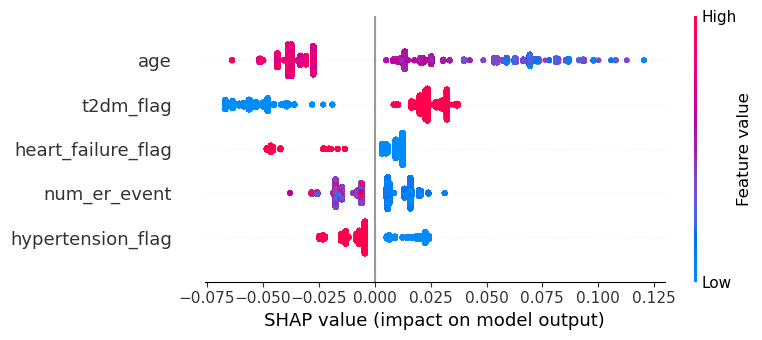

In [ ]:
# SHAP values for the tree
import shap
explainer = shap.TreeExplainer(proxy_tree)
shap_values = explainer.shap_values(X_tau_clinical)

# Visualize the SHAP values
shap.summary_plot(shap_values, X_tau_clinical, feature_names=feature_names_clinical, max_display=5)


Building ITE-RD posterior arrays …
  ite_rd shape        : (10000, 65417)
  rd_treated shape    : (10000, 13547)
  mean(CATT)          : -0.03923

── A: GATES plot ──


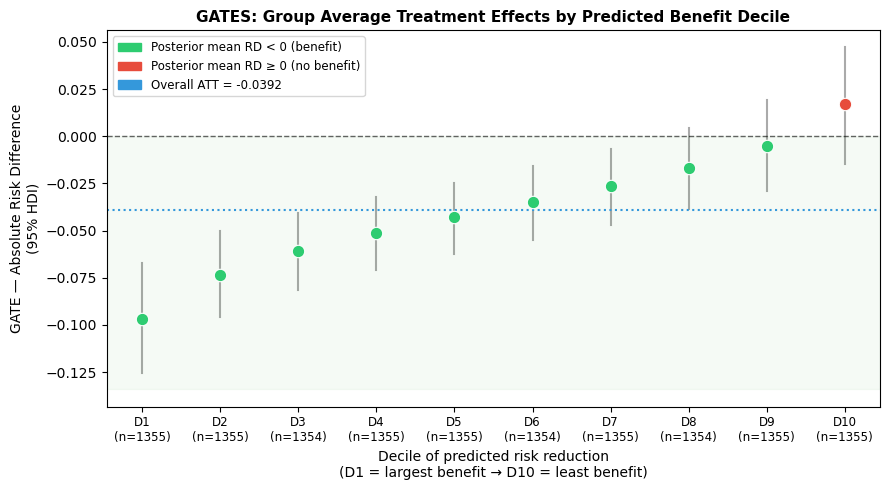

 decile    n  gate_mean        lo        hi  p_benefit
      1 1355  -0.096942 -0.125545 -0.067412     1.0000
      2 1355  -0.073483 -0.095981 -0.050418     1.0000
      3 1354  -0.060952 -0.081309 -0.040887     1.0000
      4 1355  -0.051266 -0.070849 -0.032382     1.0000
      5 1355  -0.043004 -0.062444 -0.024865     0.9999
      6 1354  -0.034905 -0.054774 -0.015550     0.9996
      7 1355  -0.026543 -0.046982 -0.007022     0.9932
      8 1354  -0.016886 -0.038519  0.004284     0.9417
      9 1355  -0.005117 -0.029241  0.019315     0.6669
     10 1355   0.016847 -0.014739  0.047065     0.1395


In [ ]:
# ── Step 0: (Re)build ITE-RD posterior ───────────────────────────────
print("Building ITE-RD posterior arrays …")
ite_rd, rd_treated, mean_rd_treated, treated_mask = build_ite_rd(
    trace_bcf, X_mu, X_tau, T, constant_intercept, mu_term="mu_residual")
print(f"  ite_rd shape        : {ite_rd.shape}")
print(f"  rd_treated shape    : {rd_treated.shape}")
print(f"  mean(CATT)          : {rd_treated.mean():.5f}")

# ── A: GATES ─────────────────────────────────────────────────────────
print("\n── A: GATES plot ──")
gates_df = plot_gates(
    rd_treated, mean_rd_treated,
    n_deciles=10,
    save_path="fig_gates_rd.png"
)
print(gates_df.to_string(index=False))


In [ ]:
# ── B: CLAN ──────────────────────────────────────────────────────────
print("\n── B: CLAN table ──")
clan_df = build_clan_table(
    mean_rd_treated, X, T,
    top_pct=0.10
)
print_clan_table(clan_df, top_pct=0.10)


── B: CLAN table ──

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  CLAN Table — Top 10% Maximum-Benefit Subgroup (D1) vs Rest of Treated
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Variable                             Type         D1 - high benefit (n=1355) Rest of treated (n=12192)   Absolute Difference                  SMD
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Age                                  continuous   69.54 ± 8.80               57.70 ± 13.40                             11.84                 1.04
Logit Propensity Score               continuous   -1.37 ± 0.94               -0.68 ± 1.00                               0.69                 0.71
Type 2 Diabetes                      binary  

In [ ]:
clan_df = build_clan_table(
    mean_rd_treated, X, T,
    top_pct=0.90
)
print_clan_table(clan_df, top_pct=0.90)


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  CLAN Table — Top 90% Maximum-Benefit Subgroup (D1) vs Rest of Treated
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Variable                             Type         D1 - high benefit (n=1355) Rest of treated (n=12192)   Absolute Difference                  SMD
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Type 2 Diabetes                      binary       88.6%                      67.9%                                      0.21                 0.52
Age                                  continuous   53.08 ± 12.37              59.53 ± 13.46                              6.45                 0.50
Heart Failure                        binary       1.7%            

In [ ]:
# build clan table for each decile of GATES
for decile in range(1, 10):
    print(f"\n── CLAN table for GATES Decile {decile} ──")
    clan_df_decile = build_clan_table(
        mean_rd_treated, X, T,
        top_pct=decile/10,
        smd_threshold=0.10,
    )
    print_clan_table(clan_df_decile, top_pct=decile/10)


── CLAN table for GATES Decile 1 ──

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  CLAN Table — Top 10% Maximum-Benefit Subgroup (D1) vs Rest of Treated
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Variable                             Type         D1 - high benefit (n=1355) Rest of treated (n=12192)   Absolute Difference                  SMD
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Age                                  continuous   69.54 ± 8.80               57.70 ± 13.40                             11.84                 1.04
Logit Propensity Score               continuous   -1.37 ± 0.94               -0.68 ± 1.00                               0.69                 0.71
Type 2 Diabetes              

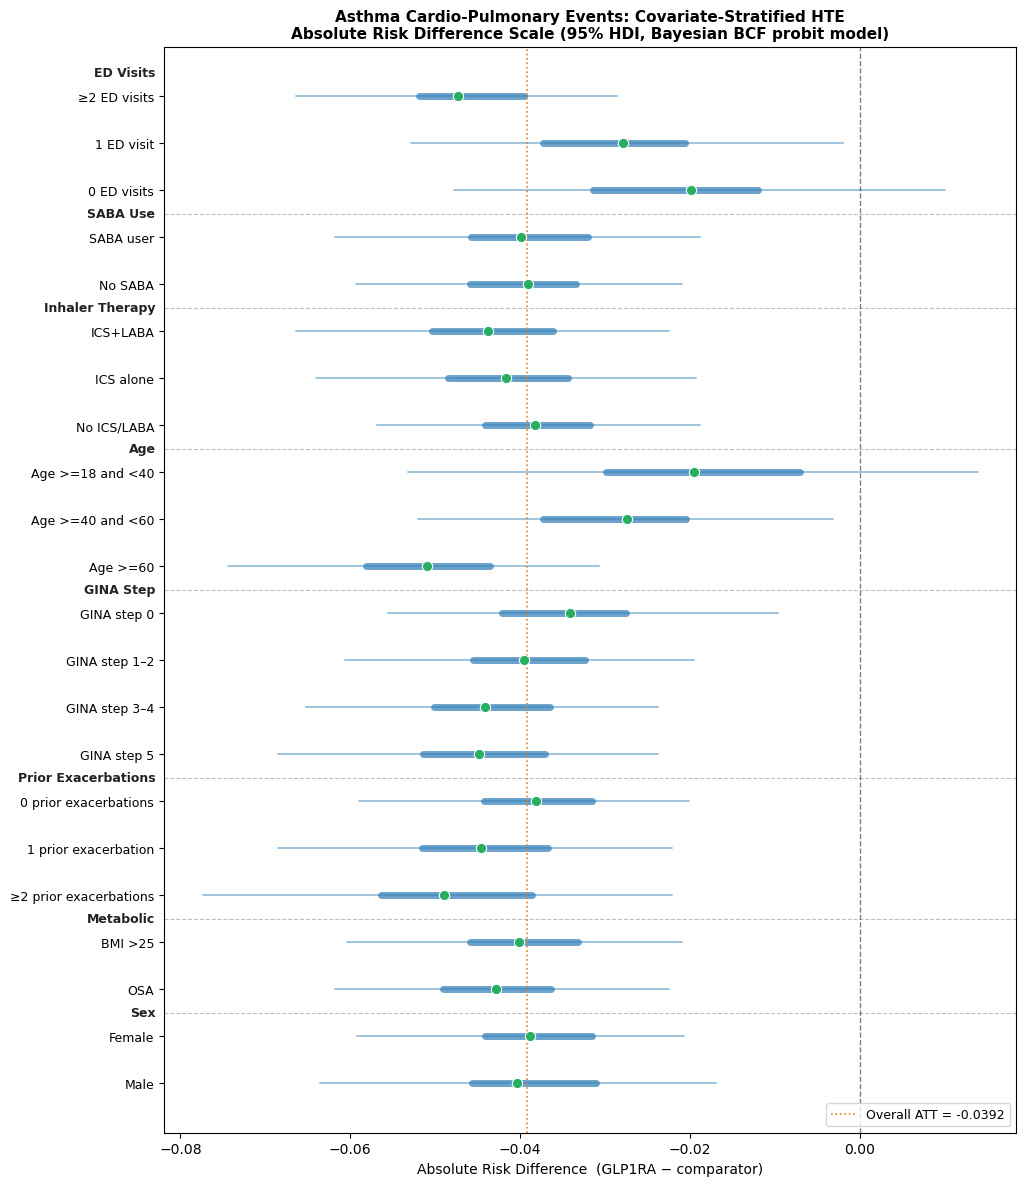

              group                  label     n      mean      lo95      hi95  p_benefit
          ED Visits           ≥2 ED visits  9038 -0.047266 -0.066398 -0.028532     0.9999
          ED Visits             1 ED visit  1851 -0.027858 -0.052867 -0.001990     0.9814
          ED Visits            0 ED visits  2658 -0.019801 -0.047792  0.010059     0.9097
           SABA Use              SABA user  2524 -0.039929 -0.061810 -0.018752     0.9998
           SABA Use                No SABA 11023 -0.039064 -0.059251 -0.020917     0.9997
    Inhaler Therapy               ICS+LABA  2401 -0.043808 -0.066430 -0.022487     1.0000
    Inhaler Therapy              ICS alone   525 -0.041689 -0.064067 -0.019231     0.9997
    Inhaler Therapy            No ICS/LABA 11146 -0.038238 -0.056828 -0.018832     0.9997
                Age       Age >=18 and <40  1382 -0.019513 -0.053235  0.013921     0.8703
                Age       Age >=40 and <60  4906 -0.027406 -0.052000 -0.003087     0.9836
          

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# CELL C — HTE Forest Plot on the absolute Risk Difference scale
# Assumes: ite_rd, X, T, constant_intercept are in scope from Cell A
# ══════════════════════════════════════════════════════════════════════════

def rd_stratum(ite_rd, full_mask, T_arr, hdi_prob=0.95):
    """CATE among treated patients within full_mask."""
    mask = full_mask & T_arr.astype(bool)
    if mask.sum() < 20:
        return None
    draws      = ite_rd[:, mask].mean(axis=1)
    hdi_v      = az.hdi(draws, hdi_prob=hdi_prob)
    lo50, hi50 = az.hdi(draws, hdi_prob=0.50)
    return dict(mean=draws.mean(), lo95=hdi_v[0], hi95=hdi_v[1],
                lo50=lo50, hi50=hi50,
                p_benefit=float((draws < 0).mean()), n=int(mask.sum()))

Xd = X.reset_index(drop=True)

strata = [
    ("≥2 ED visits",          "ED Visits",          (Xd["num_er_event"] >= 2).values),
    ("1 ED visit",            "ED Visits",          (Xd["num_er_event"] == 1).values),
    ("0 ED visits",           "ED Visits",          (Xd["num_er_event"] == 0).values),
    ("SABA user",             "SABA Use",           (Xd["SABA_flag"] == 1).values),
    ("No SABA",               "SABA Use",           (Xd["SABA_flag"] == 0).values),
    ("ICS+LABA",              "Inhaler Therapy",    (Xd["ICS_LABA_flag"] == 1).values),
    ("ICS alone",             "Inhaler Therapy",    ((Xd["ICS_flag"]==1)).values),
    ("No ICS/LABA",           "Inhaler Therapy",    (Xd["ICS_LABA_flag"] == 0).values),
    ("Age >=18 and <40",       "Age",               ((Xd["age"] >= 18) & (Xd["age"] < 40)).values),
    ("Age >=40 and <60",       "Age",               ((Xd["age"] >= 40) & (Xd["age"] < 60)).values),
    ("Age >=60",               "Age",               (Xd["age"] >= 60).values),
    ("GINA step 0",           "GINA Step",          (Xd["gina_step"] == 0).values),
    ("GINA step 1–2",         "GINA Step",          ((Xd["gina_step"]>=1)&(Xd["gina_step"]<=2)).values),
    ("GINA step 3–4",         "GINA Step",          ((Xd["gina_step"]>=3)&(Xd["gina_step"]<=4)).values),
    ("GINA step 5",           "GINA Step",          (Xd["gina_step"] == 5).values),
    ("0 prior exacerbations", "Prior Exacerbations",(Xd["total_exac_count"] == 0).values),
    ("1 prior exacerbation",  "Prior Exacerbations",(Xd["total_exac_count"] == 1).values),
    ("≥2 prior exacerbations","Prior Exacerbations",(Xd["total_exac_count"] >= 2).values),
    ("BMI >25",               "Metabolic",          (Xd["bmi_above_25"] == 1).values),
    ("OSA",                   "Metabolic",          (Xd["obstructive_sleep_apnea_flag"]==1).values),
    ("Female",                "Sex",                (Xd["sex_Female"] == 1).values),
    ("Male",                  "Sex",                (Xd["sex_Female"] == 0).values),
]

rows = []
for label, group, mask in strata:
    r = rd_stratum(ite_rd, mask, T)
    if r:
        rows.append({"label": label, "group": group, **r})

forest_df = pd.DataFrame(rows)

# ── Draw ──────────────────────────────────────────────────────────────────
n_r    = len(forest_df)
colour = "#2c7bb6"
fig, ax = plt.subplots(figsize=(11, max(6, 0.55 * n_r + 2)))

y_pos          = np.arange(n_r)[::-1]
current_group  = None

for i, (_, row) in enumerate(forest_df.iterrows()):
    y = y_pos[i]
    if row["group"] != current_group:
        current_group = row["group"]
        # add line break and group label
        if i > 0:
            ax.axhline(y + 0.5, color="gray", lw=0.8, ls="--", alpha=0.5)
        ax.text(-0.01, y + 0.5, row["group"],
                transform=ax.get_yaxis_transform(),
                ha="right", va="center",
                fontsize=9, fontweight="bold", color="#222222")
        # add more space above and below group label

    ax.plot([row["lo95"], row["hi95"]], [y, y],
            color=colour, lw=1.4, alpha=0.45, solid_capstyle="round")
    ax.plot([row["lo50"], row["hi50"]], [y, y],
            color=colour, lw=5,   alpha=0.70, solid_capstyle="round")
    dot_c = "#27ae60" if row["mean"] < 0 else "#e74c3c"
    ax.scatter(row["mean"], y, s=55, color=dot_c, zorder=5,
               edgecolors="white", linewidths=0.8)
    # ax.text(forest_df["hi95"].max() + 0.001, y,
    #         f"  {row['mean']:+.4f} [{row['lo95']:+.4f}, {row['hi95']:+.4f}]  "
    #         f"P(benefit)={row['p_benefit']:.2f}  n={row['n']}",
    #         va="center", fontsize=7.5, color="gray")

att_mean = ite_rd[:, T.astype(bool)].mean()
ax.axvline(0,        color="black",   lw=1,   ls="--", alpha=0.5)
ax.axvline(att_mean, color="#e67e22", lw=1.2, ls=":",
           label=f"Overall ATT = {att_mean:.4f}")

ax.set_yticks(y_pos)
ax.set_yticklabels(forest_df["label"].tolist(), fontsize=9)
ax.set_xlabel(
    "Absolute Risk Difference  (GLP1RA − comparator)",
    fontsize=10)
ax.set_title(
    "Asthma Cardio-Pulmonary Events: Covariate-Stratified HTE\n"
    "Absolute Risk Difference Scale (95% HDI, Bayesian BCF probit model)",
    fontsize=11, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
#fig.tight_layout()
plt.show()
print(forest_df[["group","label","n","mean","lo95","hi95","p_benefit"]].to_string(index=False))

In [ ]:
att_draws = ite_rd[:, treated_mask].mean(axis=1)
att_mean  = att_draws.mean()
ax.axvline(att_mean, color="#e67e22", lw=1.2, linestyle=":",
            label=f"Overall ATT = {att_mean:.4f}")
att_hdi = az.hdi(att_draws, hdi_prob=0.95)
print(f"Overall ATT = {att_mean:.4f} \n      95% HDI: {att_hdi[0]:.4f} to {att_hdi[1]:.4f}")


Overall ATT = -0.0392 
      95% HDI: -0.0584 to -0.0210
